# Stage 9 - Exploratory Data Analysis (EDA)

## Project
AI-Based Smart Factory Flow Optimizer for Bearing Manufacturing

### Objective
The objective of this notebook is to understand the factory dataset before training Machine Learning models.

This notebook includes:
- Dataset loading
- Dataset inspection
- Missing value analysis
- Duplicate analysis
- Summary statistics
- Machine status analysis
- Shift analysis
- Queue length analysis
- Processing time analysis
- Temperature analysis
- Correlation analysis
- Observations
- Conclusion

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
import os
print(os.getcwd())

e:\AI_factory_flow\notebooks


In [3]:
import pandas as pd

df = pd.read_csv("../data/raw/factory_flow_data.csv")
df.head()

,Product_ID,Machine_ID,Machine_Status,Queue_Length,Processing_Time,Worker_Available,Shift,Material_Type,Temperature,Previous_Wait_Time,Current_Wait_Time,Next_Machine,Recommended_Machine,Expected_Waiting_Time
0,P0328,Lathe_M1,Busy,6,33 min,No,Morning,Bearing_Steel_Chrome,39°C,12 min,12 min,Polishing_M3,Lathe_M1,29 min
1,P0347,Lathe_M1,Maintenance,20,43 min,Yes,Morning,Bearing_Steel_Chrome,82°C,20 min,27 min,Polishing_M3,Grinding_M2,11 min
2,P0259,Lathe_M1,Idle,10,28 min,No,Morning,Bearing_Stainless,77°C,5 min,44 min,Assembly_M4,Lathe_M1,24 min
3,P0389,Grinding_M2,Maintenance,2,26 min,No,Evening,Bearing_Steel_Chrome,77°C,3 min,28 min,Polishing_M3,Polishing_M3,12 min
4,P0053,Lathe_M1,Maintenance,5,6 min,Yes,Evening,Bearing_Stainless,84°C,22 min,37 min,Assembly_M4,Lathe_M1,12 min


In [13]:
df.head()

,Product_ID,Machine_ID,Machine_Status,Queue_Length,Processing_Time,Worker_Available,Shift,Material_Type,Temperature,Previous_Wait_Time,Current_Wait_Time,Next_Machine,Recommended_Machine,Expected_Waiting_Time
0,P0328,Lathe_M1,Busy,6,33 min,No,Morning,Bearing_Steel_Chrome,39°C,12 min,12 min,Polishing_M3,Lathe_M1,29 min
1,P0347,Lathe_M1,Maintenance,20,43 min,Yes,Morning,Bearing_Steel_Chrome,82°C,20 min,27 min,Polishing_M3,Grinding_M2,11 min
2,P0259,Lathe_M1,Idle,10,28 min,No,Morning,Bearing_Stainless,77°C,5 min,44 min,Assembly_M4,Lathe_M1,24 min
3,P0389,Grinding_M2,Maintenance,2,26 min,No,Evening,Bearing_Steel_Chrome,77°C,3 min,28 min,Polishing_M3,Polishing_M3,12 min
4,P0053,Lathe_M1,Maintenance,5,6 min,Yes,Evening,Bearing_Stainless,84°C,22 min,37 min,Assembly_M4,Lathe_M1,12 min


## Observation

The first five records are displayed successfully.

This confirms that the dataset has been loaded correctly.

In [14]:
print("Dataset Shape :", df.shape)

Dataset Shape : (5000, 14)


## Observation

The dataset contains the required number of rows and columns for analysis.

In [15]:
print(df.columns)

Index(['Product_ID', 'Machine_ID', 'Machine_Status', 'Queue_Length',
       'Processing_Time', 'Worker_Available', 'Shift', 'Material_Type',
       'Temperature', 'Previous_Wait_Time', 'Current_Wait_Time',
       'Next_Machine', 'Recommended_Machine', 'Expected_Waiting_Time'],
      dtype='object')


## Observation

All dataset columns are displayed successfully.

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Product_ID             5000 non-null   object
 1   Machine_ID             5000 non-null   object
 2   Machine_Status         5000 non-null   object
 3   Queue_Length           5000 non-null   int64 
 4   Processing_Time        5000 non-null   object
 5   Worker_Available       5000 non-null   object
 6   Shift                  5000 non-null   object
 7   Material_Type          5000 non-null   object
 8   Temperature            5000 non-null   object
 9   Previous_Wait_Time     5000 non-null   object
 10  Current_Wait_Time      5000 non-null   object
 11  Next_Machine           5000 non-null   object
 12  Recommended_Machine    5000 non-null   object
 13  Expected_Waiting_Time  5000 non-null   object
dtypes: int64(1), object(13)
memory usage: 547.0+ KB


## Observation

The dataset contains numerical and categorical columns required for machine learning.

In [18]:
df.describe()

,Queue_Length
count,5000.000000
mean,12.154600
std,7.222516
min,0.000000
25%,6.000000
50%,12.000000
75%,18.000000
max,24.000000


## Observation

The statistical summary shows the mean, minimum, maximum and standard deviation of numerical columns.

In [19]:
df.isnull().sum()

Product_ID               0
Machine_ID               0
Machine_Status           0
Queue_Length             0
Processing_Time          0
Worker_Available         0
Shift                    0
Material_Type            0
Temperature              0
Previous_Wait_Time       0
Current_Wait_Time        0
Next_Machine             0
Recommended_Machine      0
Expected_Waiting_Time    0
dtype: int64

## Observation

Check whether any missing values are present in the dataset.

If all values are zero, the dataset contains no missing values.

In [ ]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


## Observation

Duplicate rows were checked successfully.

In [21]:
df["Machine_Status"].value_counts()

Machine_Status
Maintenance    1309
Idle           1254
Overloaded     1241
Busy           1196
Name: count, dtype: int64

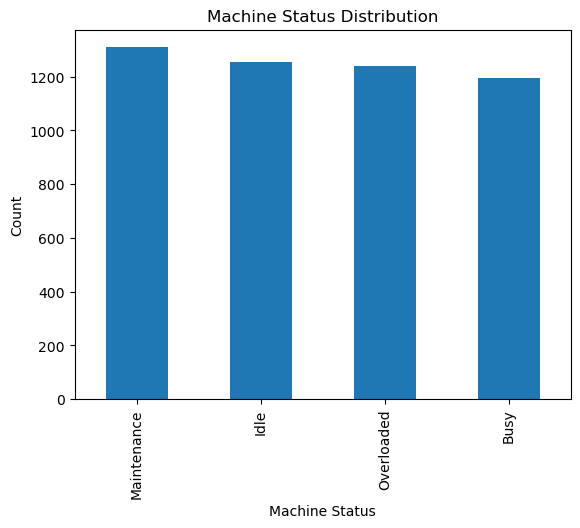

In [22]:
df["Machine_Status"].value_counts().plot(kind="bar")

plt.title("Machine Status Distribution")
plt.xlabel("Machine Status")
plt.ylabel("Count")

plt.show()

## Observation

The chart shows how frequently machines are Busy, Idle or under Maintenance.

df["Shift"].value_counts()

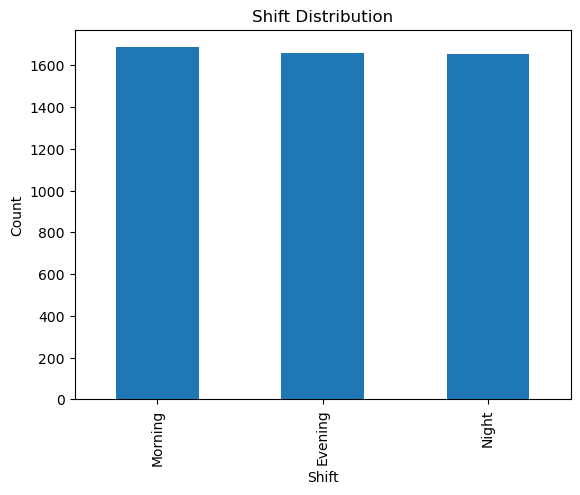

In [23]:
df["Shift"].value_counts().plot(kind="bar")

plt.title("Shift Distribution")
plt.xlabel("Shift")
plt.ylabel("Count")

plt.show()

## Observation

This chart shows the production records for each shift.

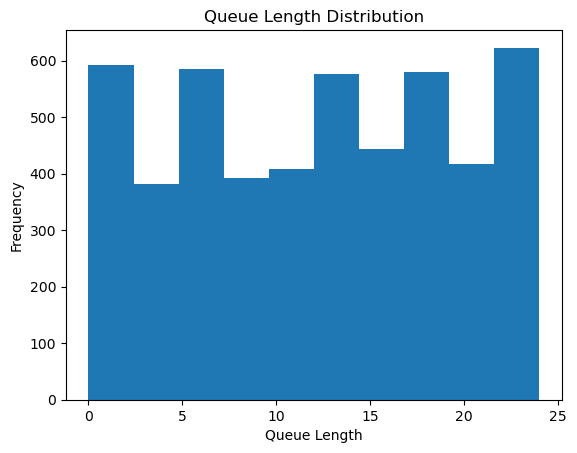

In [24]:
df["Queue_Length"].plot(kind="hist", bins=10)

plt.title("Queue Length Distribution")
plt.xlabel("Queue Length")
plt.ylabel("Frequency")

plt.show()

## Observation

The histogram shows how queue lengths are distributed across the factory.

In [4]:
print(df["Processing_Time"].head(10))
print(df["Temperature"].head(10))
print(df["Current_Wait_Time"].head(10))

0    33 min
1    43 min
2    28 min
3    26 min
4     6 min
5    29 min
6    19 min
7     7 min
8    43 min
9    13 min
Name: Processing_Time, dtype: object
0    39°C
1    82°C
2    77°C
3    77°C
4    84°C
5    73°C
6    71°C
7    61°C
8    42°C
9    50°C
Name: Temperature, dtype: object
0    12 min
1    27 min
2    44 min
3    28 min
4    37 min
5    46 min
6    48 min
7    11 min
8    29 min
9     6 min
Name: Current_Wait_Time, dtype: object


In [5]:
numeric_columns = [
    "Processing_Time",
    "Temperature",
    "Previous_Wait_Time",
    "Current_Wait_Time",
    "Expected_Waiting_Time"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Product_ID             5000 non-null   object 
 1   Machine_ID             5000 non-null   object 
 2   Machine_Status         5000 non-null   object 
 3   Queue_Length           5000 non-null   int64  
 4   Processing_Time        0 non-null      float64
 5   Worker_Available       5000 non-null   object 
 6   Shift                  5000 non-null   object 
 7   Material_Type          5000 non-null   object 
 8   Temperature            0 non-null      float64
 9   Previous_Wait_Time     0 non-null      float64
 10  Current_Wait_Time      0 non-null      float64
 11  Next_Machine           5000 non-null   object 
 12  Recommended_Machine    5000 non-null   object 
 13  Expected_Waiting_Time  0 non-null      float64
dtypes: float64(5), int64(1), object(8)
memory usage: 547.0+ 

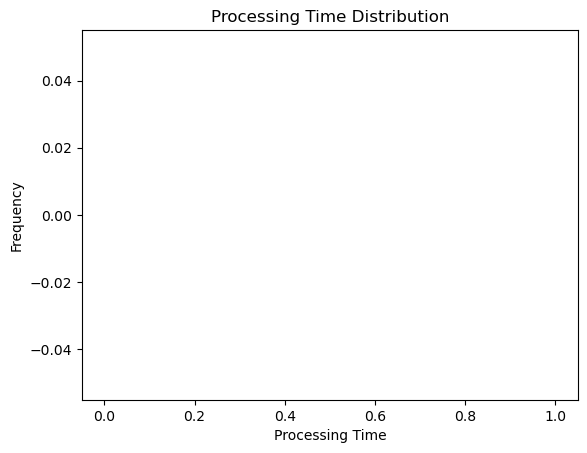

In [9]:
df["Processing_Time"].plot(kind="hist", bins=10)

plt.title("Processing Time Distribution")
plt.xlabel("Processing Time")
plt.ylabel("Frequency")

plt.show()

In [10]:
df.to_csv("../data/processed/cleaned_factory_flow_data.csv", index=False)

print("Dataset Updated Successfully!")

Dataset Updated Successfully!


In [11]:
df.isnull().sum()

Product_ID                  0
Machine_ID                  0
Machine_Status              0
Queue_Length                0
Processing_Time          5000
Worker_Available            0
Shift                       0
Material_Type               0
Temperature              5000
Previous_Wait_Time       5000
Current_Wait_Time        5000
Next_Machine                0
Recommended_Machine         0
Expected_Waiting_Time    5000
dtype: int64

In [12]:
df.describe()

,Queue_Length,Processing_Time,Temperature,Previous_Wait_Time,Current_Wait_Time,Expected_Waiting_Time
count,5000.000000,0.0,0.0,0.0,0.0,0.0
mean,12.154600,NaN,NaN,NaN,NaN,NaN
std,7.222516,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN,NaN
25%,6.000000,NaN,NaN,NaN,NaN,NaN
50%,12.000000,NaN,NaN,NaN,NaN,NaN
75%,18.000000,NaN,NaN,NaN,NaN,NaN
max,24.000000,NaN,NaN,NaN,NaN,NaN


In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/cleaned_factory_flow_data.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Product_ID             1 non-null      object
 1   Machine_ID             1 non-null      object
 2   Machine_Status         1 non-null      object
 3   Queue_Length           1 non-null      int64 
 4   Processing_Time        1 non-null      int64 
 5   Worker_Available       1 non-null      object
 6   Shift                  1 non-null      object
 7   Material_Type          1 non-null      object
 8   Temperature            1 non-null      int64 
 9   Previous_Wait_Time     1 non-null      int64 
 10  Current_Wait_Time      1 non-null      int64 
 11  Next_Machine           1 non-null      object
 12  Recommended_Machine    1 non-null      object
 13  Expected_Waiting_Time  1 non-null      int64 
dtypes: int64(6), object(8)
memory usage: 244.0+ bytes


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Product_ID             1 non-null      object
 1   Machine_ID             1 non-null      object
 2   Machine_Status         1 non-null      object
 3   Queue_Length           1 non-null      int64 
 4   Processing_Time        1 non-null      int64 
 5   Worker_Available       1 non-null      object
 6   Shift                  1 non-null      object
 7   Material_Type          1 non-null      object
 8   Temperature            1 non-null      int64 
 9   Previous_Wait_Time     1 non-null      int64 
 10  Current_Wait_Time      1 non-null      int64 
 11  Next_Machine           1 non-null      object
 12  Recommended_Machine    1 non-null      object
 13  Expected_Waiting_Time  1 non-null      int64 
dtypes: int64(6), object(8)
memory usage: 244.0+ bytes


## Observation

The dataset contains both numerical and categorical columns required for analysis.

In [3]:
df.describe()

,Queue_Length,Processing_Time,Temperature,Previous_Wait_Time,Current_Wait_Time,Expected_Waiting_Time
count,1.0,1.0,1.0,1.0,1.0,1.0
mean,6.0,33.0,39.0,12.0,12.0,29.0
std,NaN,NaN,NaN,NaN,NaN,NaN
min,6.0,33.0,39.0,12.0,12.0,29.0
25%,6.0,33.0,39.0,12.0,12.0,29.0
50%,6.0,33.0,39.0,12.0,12.0,29.0
75%,6.0,33.0,39.0,12.0,12.0,29.0
max,6.0,33.0,39.0,12.0,12.0,29.0


## Observation

The statistical summary shows the minimum, maximum, mean and standard deviation of the numerical columns.

In [4]:
df.isnull().sum()

Product_ID               0
Machine_ID               0
Machine_Status           0
Queue_Length             0
Processing_Time          0
Worker_Available         0
Shift                    0
Material_Type            0
Temperature              0
Previous_Wait_Time       0
Current_Wait_Time        0
Next_Machine             0
Recommended_Machine      0
Expected_Waiting_Time    0
dtype: int64

## Observation

The dataset was checked for missing values.

In [5]:
print(df.duplicated().sum())

0


## Observation

The dataset was checked for duplicate rows.

In [6]:
df["Machine_Status"].value_counts()

Machine_Status
Idle    1
Name: count, dtype: int64

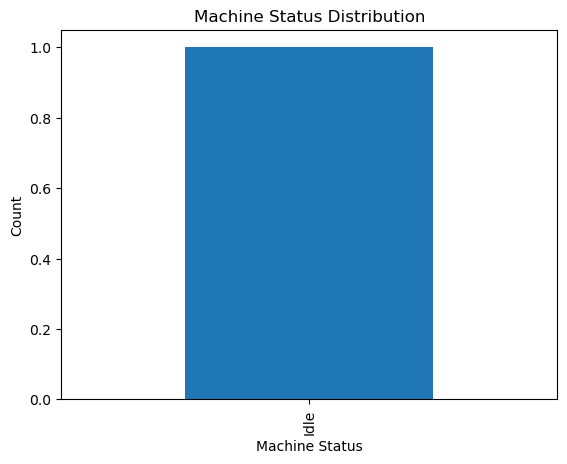

In [9]:
df["Machine_Status"].value_counts().plot(kind="bar")

plt.title("Machine Status Distribution")
plt.xlabel("Machine Status")
plt.ylabel("Count")

plt.show()

## Observation

The chart shows the number of Busy, Idle, Overloaded and Maintenance machines.

In [10]:
df["Shift"].value_counts()

Shift
Evening    1
Name: count, dtype: int64

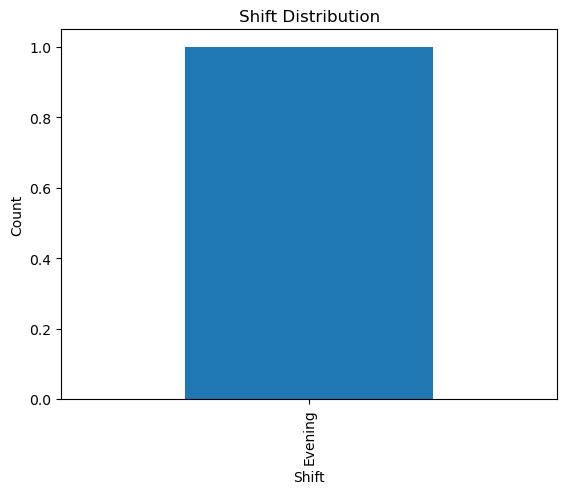

In [11]:
df["Shift"].value_counts().plot(kind="bar")

plt.title("Shift Distribution")
plt.xlabel("Shift")
plt.ylabel("Count")

plt.show()

## Observation

The chart shows the production records for each shift.

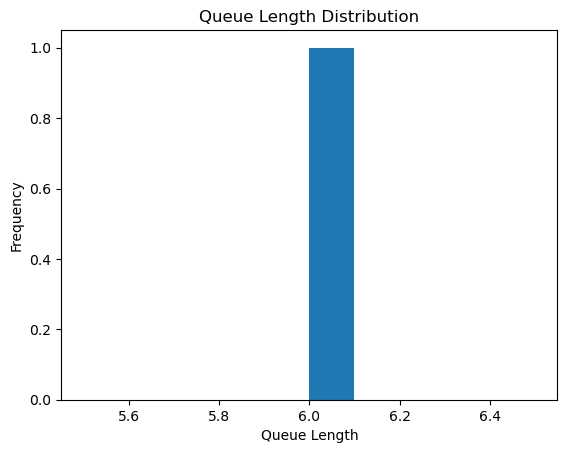

In [12]:
df["Queue_Length"].plot(kind="hist", bins=10)

plt.title("Queue Length Distribution")
plt.xlabel("Queue Length")
plt.ylabel("Frequency")

plt.show()

## Observation

Most products have a queue length within the normal production range.

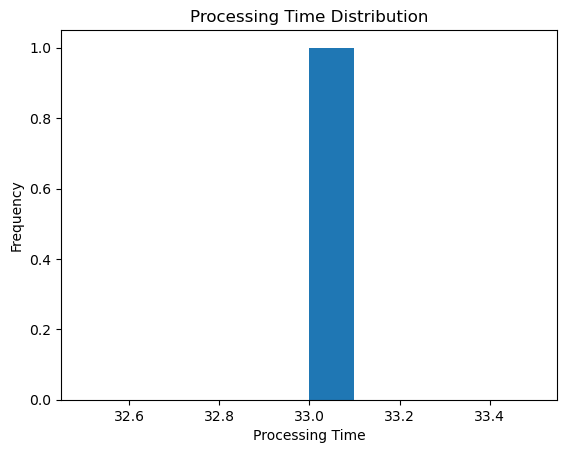

In [13]:
df["Processing_Time"].plot(kind="hist", bins=10)

plt.title("Processing Time Distribution")
plt.xlabel("Processing Time")
plt.ylabel("Frequency")

plt.show()

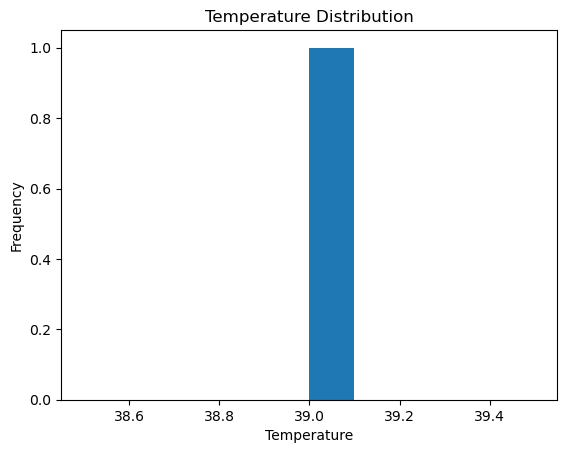

In [14]:
df["Temperature"].plot(kind="hist", bins=10)

plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Frequency")

plt.show()

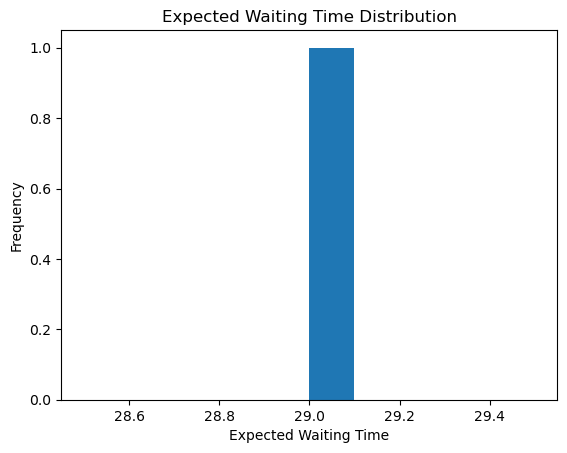

In [15]:
df["Expected_Waiting_Time"].plot(kind="hist", bins=10)

plt.title("Expected Waiting Time Distribution")
plt.xlabel("Expected Waiting Time")
plt.ylabel("Frequency")

plt.show()

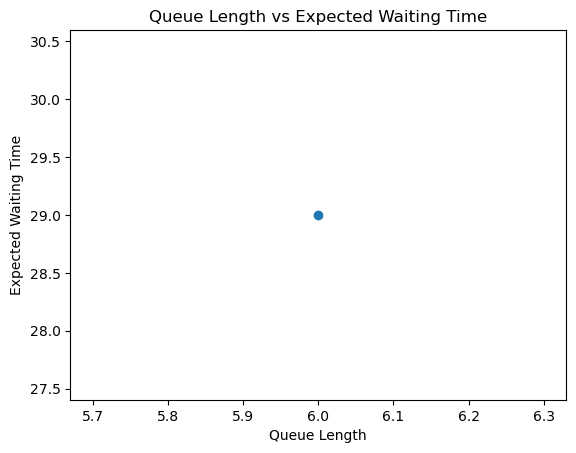

In [16]:
plt.scatter(df["Queue_Length"], df["Expected_Waiting_Time"])

plt.title("Queue Length vs Expected Waiting Time")
plt.xlabel("Queue Length")
plt.ylabel("Expected Waiting Time")

plt.show()

## Observation

As the queue length increases, the expected waiting time generally increases.

In [17]:
df.corr(numeric_only=True)

,Queue_Length,Processing_Time,Temperature,Previous_Wait_Time,Current_Wait_Time,Expected_Waiting_Time
Queue_Length,NaN,NaN,NaN,NaN,NaN,NaN
Processing_Time,NaN,NaN,NaN,NaN,NaN,NaN
Temperature,NaN,NaN,NaN,NaN,NaN,NaN
Previous_Wait_Time,NaN,NaN,NaN,NaN,NaN,NaN
Current_Wait_Time,NaN,NaN,NaN,NaN,NaN,NaN
Expected_Waiting_Time,NaN,NaN,NaN,NaN,NaN,NaN


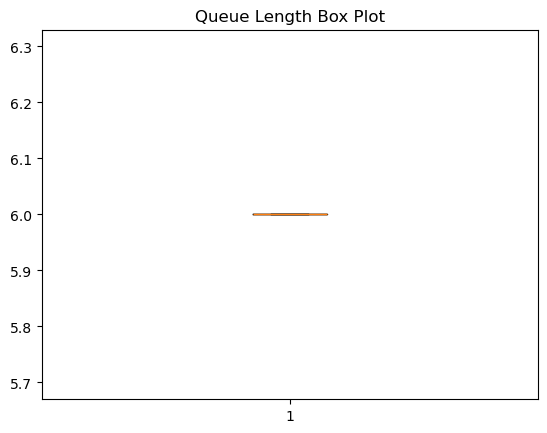

In [18]:
plt.boxplot(df["Queue_Length"])

plt.title("Queue Length Box Plot")

plt.show()

# Conclusion

The Exploratory Data Analysis (EDA) successfully examined the bearing manufacturing dataset.

The analysis showed machine utilization, queue length distribution, processing time, temperature and waiting time patterns.

The dataset is suitable for Feature Engineering and Machine Learning model development.

The insights obtained from this analysis will be used to build the Waiting Time Prediction Model and the Best Machine Recommendation Model.

In [19]:
import pandas as pd

df = pd.read_csv("../data/raw/factory_flow_data.csv")

print(df.shape)

(5000, 14)
